# Checking different parameters for bitcoin

In [1]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
import pandas as pd

# Load BTC CSV
btc_df = pd.read_csv(r'feature_datasets\BTC_features.csv', parse_dates=True, index_col=0)

# Define X and y
btc_y = btc_df['Close'].shift(-1)          # next-day close price
btc_X = btc_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
btc_X = btc_X.iloc[:-1]
btc_y = btc_y.iloc[:-1]

# check shapes
print("BTC X shape:", btc_X.shape)
print("BTC y shape:", btc_y.shape)

BTC X shape: (915, 29)
BTC y shape: (915,)


In [3]:
# 70% train / 30% test split (time-based)
split_idx = int(len(btc_X) * 0.7)

btc_X_train = btc_X.iloc[:split_idx].values
btc_X_test  = btc_X.iloc[split_idx:].values

btc_y_train = btc_y.iloc[:split_idx].values
btc_y_test  = btc_y.iloc[split_idx:].values

# Optional: check shapes
print("BTC X_train shape:", btc_X_train.shape)
print("BTC X_test shape:", btc_X_test.shape)
print("BTC y_train shape:", btc_y_train.shape)
print("BTC y_test shape:", btc_y_test.shape)

BTC X_train shape: (640, 29)
BTC X_test shape: (275, 29)
BTC y_train shape: (640,)
BTC y_test shape: (275,)


In [4]:
btc_test_dates = btc_df.index[-len(btc_X_test):]

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
btc_X_train_scaled = scaler.fit_transform(btc_X_train)

# Transform TEST using the same scaler
btc_X_test_scaled = scaler.transform(btc_X_test)

# Check shapes
print("Scaled X_train shape:", btc_X_train_scaled.shape)
print("Scaled X_test shape:", btc_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [6]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
btc_y_train_scaled = y_scaler.fit_transform(btc_y_train.reshape(-1,1)).flatten()

# Scale test target
btc_y_test_scaled = y_scaler.transform(btc_y_test.reshape(-1,1)).flatten()

In [7]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for BTC using scaled target
btc_X_train_seq, btc_y_train_seq = create_sequences(btc_X_train_scaled, btc_y_train_scaled, time_steps=30)
btc_X_test_seq, btc_y_test_seq = create_sequences(btc_X_test_scaled, btc_y_test_scaled, time_steps=30)

# Check shapes
print("BTC X_train_seq shape:", btc_X_train_seq.shape)
print("BTC y_train_seq shape:", btc_y_train_seq.shape)
print("BTC X_test_seq shape:", btc_X_test_seq.shape)
print("BTC y_test_seq shape:", btc_y_test_seq.shape)

BTC X_train_seq shape: (610, 30, 29)
BTC y_train_seq shape: (610,)
BTC X_test_seq shape: (245, 30, 29)
BTC y_test_seq shape: (245,)


In [8]:
from BI_LSTM_New import BiLSTM, predict_model

In [9]:
# Get number of features from the sequences
input_size = btc_X_train_seq.shape[2]

## optimizer = SGD for epochs = 50

In [11]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

# Fixed best parameters
hidden_size = 78
num_layers = 2
lr = 0.0007451964123638622
batch_size = 32
epochs = 50

# Model
input_size = btc_X_train_seq.shape[2]
model = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

# DataLoader
train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Training and recording loss
epoch_losses = []

model.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

# Save all 50 epoch losses into a dataframe
loss_df = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

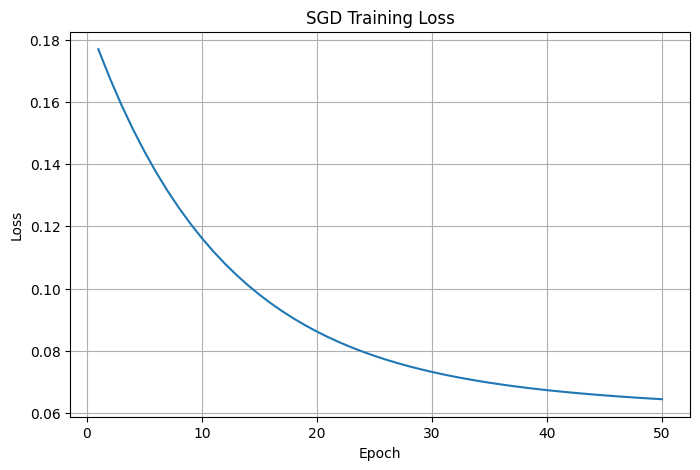

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df["Epoch"], loss_df["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD Training Loss")
plt.grid(True)
plt.show()

### Testing for SGD,50

In [14]:
btc_preds = predict_model(model, btc_X_test_seq)

# Optional: check
print("Predictions shape:", btc_preds.shape)
print("First 10 predictions:", btc_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.28297406]
 [0.2819835 ]
 [0.2816921 ]
 [0.281447  ]
 [0.28147596]
 [0.2809615 ]
 [0.2810164 ]
 [0.2806043 ]
 [0.27928805]
 [0.27914703]]


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual = btc_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(btc_y_test_actual, btc_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(btc_y_test_actual, btc_preds_actual)
r2 = r2_score(btc_y_test_actual, btc_preds_actual)
mape = np.mean(np.abs((btc_y_test_actual - btc_preds_actual) / btc_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 28333706.22
RMSE: 5322.94
MAE: 4089.13
R2 Score: 0.0804
MAPE: 12.33%


In [16]:
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = btc_df.index[-len(btc_X_test):][30:]  # test dates aligned with sequences
actual_seq = btc_y_test[30:]                      # actual prices aligned
pred_seq = btc_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,28680.537109,30439.550781
2023-05-03,29006.308594,30388.259766
2023-05-04,28847.710938,30373.171875
2023-05-05,29534.384766,30360.480469
2023-05-06,28904.623047,30361.980469
...,...,...
2023-12-28,42627.855469,31190.234375
2023-12-29,42099.402344,31029.447266
2023-12-30,42156.902344,31213.988281


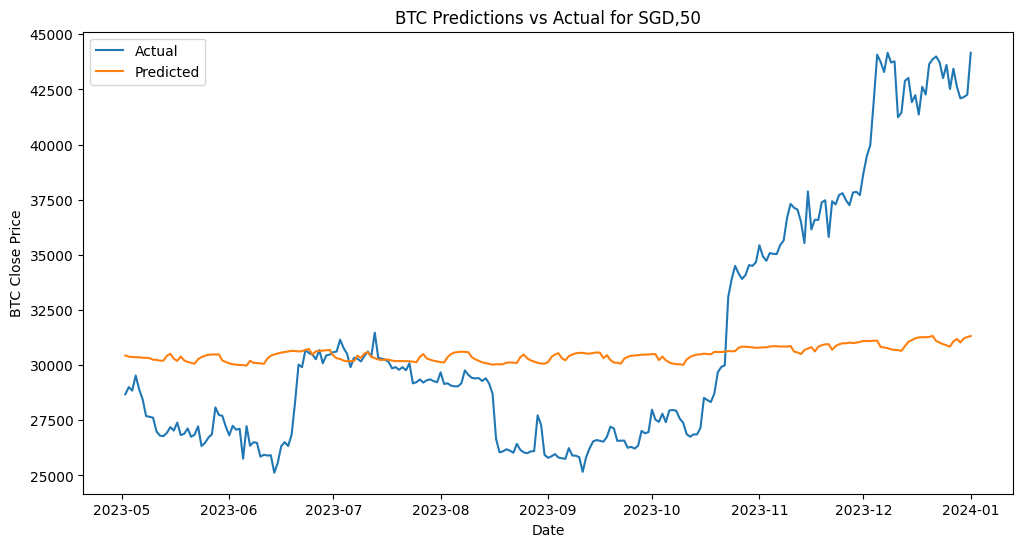

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual for SGD,50")
plt.legend()
plt.show()

## SGD,100

In [20]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

# Fixed best parameters
hidden_size = 78
num_layers = 2
lr = 0.0007451964123638622
batch_size = 32
epochs = 100

# Model
input_size = btc_X_train_seq.shape[2]
model = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

# DataLoader
train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Training and recording loss
epoch_losses = []

model.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

# Save all 50 epoch losses into a dataframe
loss_df_100 = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

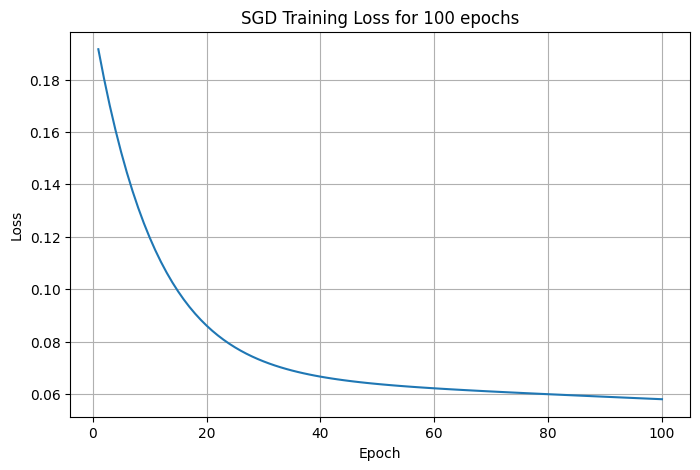

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df_100["Epoch"], loss_df_100["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD Training Loss for 100 epochs")
plt.grid(True)
plt.show()

## optimizer = RMSprop epochs =50

In [23]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

# Fixed best parameters
hidden_size = 78
num_layers = 2
lr = 0.0007451964123638622
batch_size = 32
epochs = 50

# Model
input_size = btc_X_train_seq.shape[2]
model_RMS = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_RMS = model_RMS.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.RMSprop(model_RMS.parameters(), lr=lr)

# DataLoader
train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Training and recording loss
epoch_losses = []

model_RMS.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model_RMS(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

# Save losses
loss_df_RMS = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

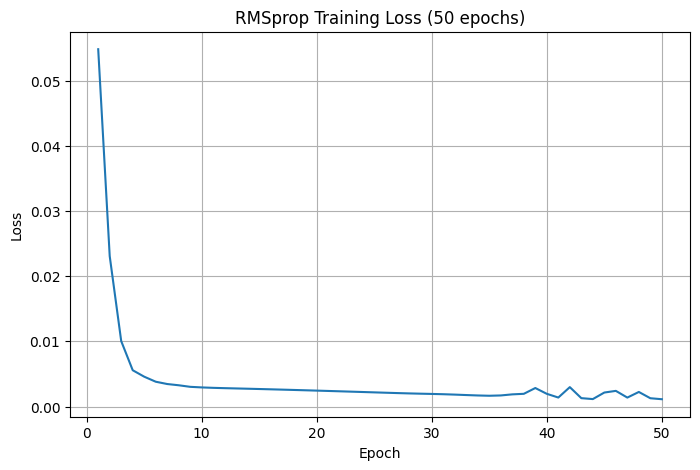

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df_RMS["Epoch"], loss_df_RMS["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RMSprop Training Loss (50 epochs)")
plt.grid(True)
plt.show()

In [27]:
btc_preds_RMS = predict_model(model_RMS, btc_X_test_seq)

# Optional: check
print("Predictions shape:", btc_preds_RMS.shape)
print("First 10 predictions:", btc_preds_RMS[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.27974626]
 [0.2679463 ]
 [0.26165262]
 [0.25491682]
 [0.24865445]
 [0.24502663]
 [0.24008647]
 [0.23314217]
 [0.22144309]
 [0.21717238]]


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_RMS_actual = y_scaler.inverse_transform(btc_preds_RMS.reshape(-1,1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual = btc_y_test[30:].reshape(-1,1)

# Calculate metrics
mse_RMS = mean_squared_error(btc_y_test_actual, btc_preds_RMS_actual)
rmse_RMS = np.sqrt(mse_RMS)
mae_RMS = mean_absolute_error(btc_y_test_actual, btc_preds_RMS_actual)
r2_RMS = r2_score(btc_y_test_actual, btc_preds_RMS_actual)
mape_RMS = np.mean(np.abs((btc_y_test_actual - btc_preds_RMS_actual) / btc_y_test_actual)) * 100

print(f"RMSprop Results:")
print(f"MSE: {mse_RMS:.2f}")
print(f"RMSE: {rmse_RMS:.2f}")
print(f"MAE: {mae_RMS:.2f}")
print(f"R2 Score: {r2_RMS:.4f}")
print(f"MAPE: {mape_RMS:.2f}%")

RMSprop Results:
MSE: 3037316.64
RMSE: 1742.79
MAE: 1196.96
R2 Score: 0.9014
MAPE: 3.41%


## Optimizer = AdamW epochs=50

In [30]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

# Fixed best parameters
hidden_size = 78
num_layers = 2
lr = 0.0007451964123638622
batch_size = 32
epochs = 50

# Model
input_size = btc_X_train_seq.shape[2]
model_ADAMW = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ADAMW = model_ADAMW.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model_ADAMW.parameters(), lr=lr)

# DataLoader
train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Training and recording loss
epoch_losses = []

model_ADAMW.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model_ADAMW(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

# Save losses
loss_df_ADAMW = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

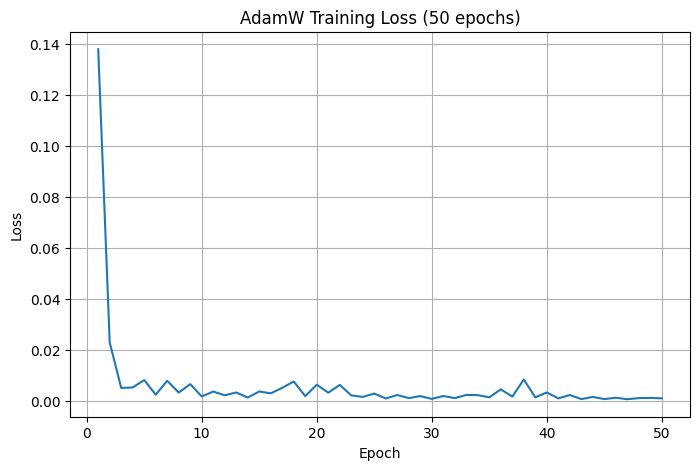

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df_ADAMW["Epoch"], loss_df_ADAMW["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AdamW Training Loss (50 epochs)")
plt.grid(True)
plt.show()

In [32]:
btc_preds_ADAMW = predict_model(model_ADAMW, btc_X_test_seq)

# Optional: check
print("Predictions shape:", btc_preds_ADAMW.shape)
print("First 10 predictions:", btc_preds_ADAMW[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.24260761]
 [0.22994666]
 [0.22266252]
 [0.21644159]
 [0.21093188]
 [0.20865688]
 [0.20477755]
 [0.19928311]
 [0.19311239]
 [0.1883745 ]]


In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_ADAMW_actual = y_scaler.inverse_transform(btc_preds_ADAMW.reshape(-1,1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual = btc_y_test[30:].reshape(-1,1)

# Calculate metrics
mse_ADAMW = mean_squared_error(btc_y_test_actual, btc_preds_ADAMW_actual)
rmse_ADAMW = np.sqrt(mse_ADAMW)
mae_ADAMW = mean_absolute_error(btc_y_test_actual, btc_preds_ADAMW_actual)
r2_ADAMW = r2_score(btc_y_test_actual, btc_preds_ADAMW_actual)
mape_ADAMW = np.mean(np.abs((btc_y_test_actual - btc_preds_ADAMW_actual) / btc_y_test_actual)) * 100

print(f"AdamW Results:")
print(f"MSE: {mse_ADAMW:.2f}")
print(f"RMSE: {rmse_ADAMW:.2f}")
print(f"MAE: {mae_ADAMW:.2f}")
print(f"R2 Score: {r2_ADAMW:.4f}")
print(f"MAPE: {mape_ADAMW:.2f}%")

AdamW Results:
MSE: 6525582.10
RMSE: 2554.52
MAE: 2082.44
R2 Score: 0.7882
MAPE: 6.23%


## optimizer = Adam epochs = 100

In [34]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

# Fixed best parameters
hidden_size = 78
num_layers = 2
lr = 0.0007451964123638622
batch_size = 32
epochs = 100

# Model
input_size = btc_X_train_seq.shape[2]
model_ADAM_100 = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ADAM_100 = model_ADAM_100.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_ADAM_100.parameters(), lr=lr)

# DataLoader
train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

# Training and recording loss
epoch_losses = []

model_ADAM_100.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model_ADAM_100(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

# Save losses
loss_df_ADAM_100 = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

In [35]:
btc_preds_ADAM_100 = predict_model(model_ADAM_100, btc_X_test_seq)

# Optional: check
print("Predictions shape:", btc_preds_ADAM_100.shape)
print("First 10 predictions:", btc_preds_ADAM_100[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.25522125]
 [0.23862925]
 [0.23112091]
 [0.22135192]
 [0.2152504 ]
 [0.21127202]
 [0.20746815]
 [0.20257582]
 [0.19238168]
 [0.1914604 ]]


In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_ADAM_100_actual = y_scaler.inverse_transform(btc_preds_ADAM_100.reshape(-1,1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual = btc_y_test[30:].reshape(-1,1)

# Calculate metrics
mse_ADAM_100 = mean_squared_error(btc_y_test_actual, btc_preds_ADAM_100_actual)
rmse_ADAM_100 = np.sqrt(mse_ADAM_100)
mae_ADAM_100 = mean_absolute_error(btc_y_test_actual, btc_preds_ADAM_100_actual)
r2_ADAM_100 = r2_score(btc_y_test_actual, btc_preds_ADAM_100_actual)
mape_ADAM_100 = np.mean(np.abs((btc_y_test_actual - btc_preds_ADAM_100_actual) / btc_y_test_actual)) * 100

print("Adam Results (100 epochs):")
print(f"MSE: {mse_ADAM_100:.2f}")
print(f"RMSE: {rmse_ADAM_100:.2f}")
print(f"MAE: {mae_ADAM_100:.2f}")
print(f"R2 Score: {r2_ADAM_100:.4f}")
print(f"MAPE: {mape_ADAM_100:.2f}%")

Adam Results (100 epochs):
MSE: 3485263.94
RMSE: 1866.89
MAE: 1397.98
R2 Score: 0.8869
MAPE: 4.13%


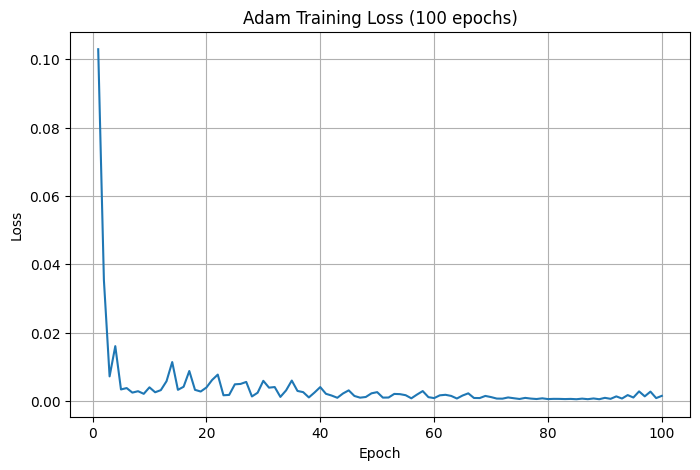

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df_ADAM_100["Epoch"], loss_df_ADAM_100["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam Training Loss (100 epochs)")
plt.grid(True)
plt.show()

# Fintuning the model to look if the performance inproves

### RMSprop optimizer 50 epoch finetuning 

In [38]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convert data once
X_train_tensor = torch.tensor(btc_X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(btc_y_train_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(btc_X_test_seq, dtype=torch.float32)

def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    epochs = trial.suggest_int("epochs", 30, 100)

    input_size = btc_X_train_seq.shape[2]

    model = BiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=1
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs.squeeze(), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor.to(device)).cpu().numpy()

    preds_actual = y_scaler.inverse_transform(preds.reshape(-1, 1))
    y_test_actual = btc_y_test[30:].reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
    return rmse

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
study_rms = optuna.create_study(direction="minimize")
study_rms.optimize(objective, n_trials=10)

[I 2026-04-03 18:34:15,648] A new study created in memory with name: no-name-e62d4ed6-594f-4227-a90d-38f73be3f622
[I 2026-04-03 18:36:05,346] Trial 0 finished with value: 2336.428260351896 and parameters: {'hidden_size': 116, 'num_layers': 3, 'lr': 0.0016573492575530663, 'batch_size': 16, 'epochs': 31}. Best is trial 0 with value: 2336.428260351896.
[I 2026-04-03 18:36:52,966] Trial 1 finished with value: 2265.3036710399397 and parameters: {'hidden_size': 45, 'num_layers': 2, 'lr': 0.002531764380582421, 'batch_size': 32, 'epochs': 74}. Best is trial 1 with value: 2265.3036710399397.
[I 2026-04-03 18:37:24,379] Trial 2 finished with value: 1069.9904537722537 and parameters: {'hidden_size': 92, 'num_layers': 1, 'lr': 0.0004718878887250954, 'batch_size': 64, 'epochs': 95}. Best is trial 2 with value: 1069.9904537722537.
[I 2026-04-03 18:39:51,458] Trial 3 finished with value: 1109.8252393437592 and parameters: {'hidden_size': 105, 'num_layers': 2, 'lr': 0.00045024458318535865, 'batch_size

In [41]:
print("Best RMSprop RMSE:", study_rms.best_value)
print("Best RMSprop Parameters:", study_rms.best_params)

Best RMSprop RMSE: 1069.9904537722537
Best RMSprop Parameters: {'hidden_size': 92, 'num_layers': 1, 'lr': 0.0004718878887250954, 'batch_size': 64, 'epochs': 95}


In [42]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

best_params_rms = study_rms.best_params

hidden_size = best_params_rms["hidden_size"]
num_layers = best_params_rms["num_layers"]
lr = best_params_rms["lr"]
batch_size = best_params_rms["batch_size"]
epochs = best_params_rms["epochs"]

input_size = btc_X_train_seq.shape[2]

model_RMS_best = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_RMS_best = model_RMS_best.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.RMSprop(model_RMS_best.parameters(), lr=lr)

train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

epoch_losses = []

model_RMS_best.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model_RMS_best(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

loss_df_RMS_best = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

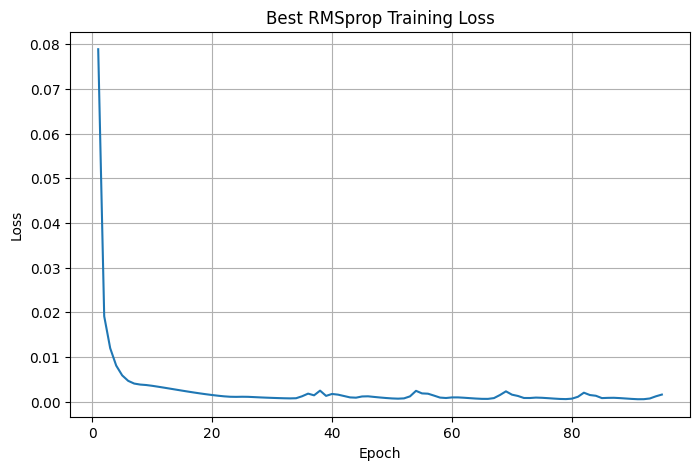

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df_RMS_best["Epoch"], loss_df_RMS_best["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best RMSprop Training Loss")
plt.grid(True)
plt.show()

In [43]:
btc_preds_RMS_best = predict_model(model_RMS_best, btc_X_test_seq)

print("Predictions shape:", btc_preds_RMS_best.shape)
print("First 10 predictions:", btc_preds_RMS_best[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.2801769 ]
 [0.26873612]
 [0.26830676]
 [0.2613546 ]
 [0.25429177]
 [0.25177243]
 [0.24410385]
 [0.23640057]
 [0.2238265 ]
 [0.21992803]]


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

btc_preds_RMS_best_actual = y_scaler.inverse_transform(btc_preds_RMS_best.reshape(-1, 1))
btc_y_test_actual = btc_y_test[30:].reshape(-1, 1)

mse_RMS_best = mean_squared_error(btc_y_test_actual, btc_preds_RMS_best_actual)
rmse_RMS_best = np.sqrt(mse_RMS_best)
mae_RMS_best = mean_absolute_error(btc_y_test_actual, btc_preds_RMS_best_actual)
r2_RMS_best = r2_score(btc_y_test_actual, btc_preds_RMS_best_actual)
mape_RMS_best = np.mean(np.abs((btc_y_test_actual - btc_preds_RMS_best_actual) / btc_y_test_actual)) * 100

print("Best RMSprop Results:")
print(f"MSE: {mse_RMS_best:.2f}")
print(f"RMSE: {rmse_RMS_best:.2f}")
print(f"MAE: {mae_RMS_best:.2f}")
print(f"R2 Score: {r2_RMS_best:.4f}")
print(f"MAPE: {mape_RMS_best:.2f}%")

Best RMSprop Results:
MSE: 651540.18
RMSE: 807.18
MAE: 610.01
R2 Score: 0.9789
MAPE: 1.95%


 ### AdamW optimizer 50 epoch finetuning 

In [46]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convert data once
X_train_tensor = torch.tensor(btc_X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(btc_y_train_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(btc_X_test_seq, dtype=torch.float32)

def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    epochs = trial.suggest_int("epochs", 30, 100)

    input_size = btc_X_train_seq.shape[2]

    model = BiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=1
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs.squeeze(), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor.to(device)).cpu().numpy()

    preds_actual = y_scaler.inverse_transform(preds.reshape(-1, 1))
    y_test_actual = btc_y_test[30:].reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
    return rmse

In [47]:
study_adamw = optuna.create_study(direction="minimize")
study_adamw.optimize(objective, n_trials=10)

[I 2026-04-03 18:50:10,524] A new study created in memory with name: no-name-8b4328f2-8b80-4a12-ba13-ce117dfeb378
[I 2026-04-03 18:51:34,920] Trial 0 finished with value: 3759.572353521826 and parameters: {'hidden_size': 68, 'num_layers': 2, 'lr': 0.009720693427822544, 'batch_size': 32, 'epochs': 82}. Best is trial 0 with value: 3759.572353521826.
[I 2026-04-03 18:52:04,312] Trial 1 finished with value: 1461.2603878381813 and parameters: {'hidden_size': 125, 'num_layers': 1, 'lr': 0.0021084487093944557, 'batch_size': 32, 'epochs': 41}. Best is trial 1 with value: 1461.2603878381813.
[I 2026-04-03 18:52:55,163] Trial 2 finished with value: 1675.7694790140717 and parameters: {'hidden_size': 108, 'num_layers': 2, 'lr': 0.0003354260958326182, 'batch_size': 64, 'epochs': 48}. Best is trial 1 with value: 1461.2603878381813.
[I 2026-04-03 18:54:16,562] Trial 3 finished with value: 1613.2603582368217 and parameters: {'hidden_size': 63, 'num_layers': 3, 'lr': 0.00039673770426755235, 'batch_size

In [48]:
print("Best AdamW RMSE:", study_adamw.best_value)
print("Best AdamW Parameters:", study_adamw.best_params)

Best AdamW RMSE: 1107.5371240788497
Best AdamW Parameters: {'hidden_size': 63, 'num_layers': 1, 'lr': 0.00038834359589297866, 'batch_size': 32, 'epochs': 55}


In [49]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

best_params_adamw = study_adamw.best_params

hidden_size = best_params_adamw["hidden_size"]
num_layers = best_params_adamw["num_layers"]
lr = best_params_adamw["lr"]
batch_size = best_params_adamw["batch_size"]
epochs = best_params_adamw["epochs"]

input_size = btc_X_train_seq.shape[2]

model_ADAMW_best = BiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=1
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ADAMW_best = model_ADAMW_best.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model_ADAMW_best.parameters(), lr=lr)

train_dataset = TensorDataset(
    torch.tensor(btc_X_train_seq, dtype=torch.float32),
    torch.tensor(btc_y_train_seq, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

epoch_losses = []

model_ADAMW_best.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model_ADAMW_best(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append([epoch + 1, avg_loss])

loss_df_ADAMW_best = pd.DataFrame(epoch_losses, columns=["Epoch", "Loss"])

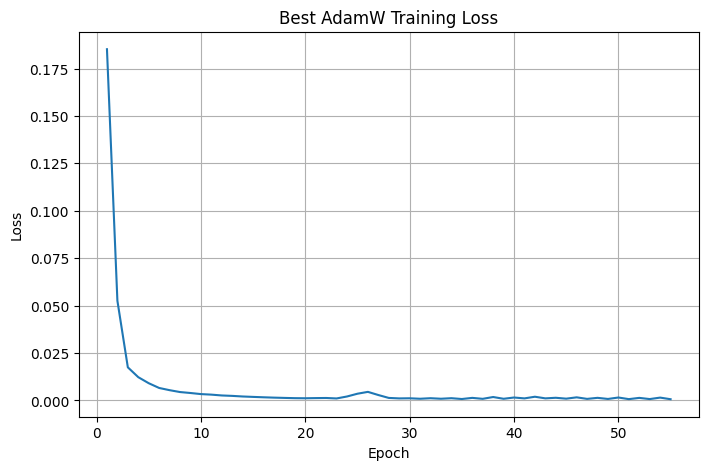

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df_ADAMW_best["Epoch"], loss_df_ADAMW_best["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best AdamW Training Loss")
plt.grid(True)
plt.show()

In [51]:
btc_preds_ADAMW_best = predict_model(model_ADAMW_best, btc_X_test_seq)

print("Predictions shape:", btc_preds_ADAMW_best.shape)
print("First 10 predictions:", btc_preds_ADAMW_best[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.27242535]
 [0.26056135]
 [0.2521359 ]
 [0.24338749]
 [0.23513219]
 [0.23049161]
 [0.2223767 ]
 [0.2124668 ]
 [0.2051734 ]
 [0.19778049]]


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

btc_preds_ADAMW_best_actual = y_scaler.inverse_transform(btc_preds_ADAMW_best.reshape(-1, 1))
btc_y_test_actual = btc_y_test[30:].reshape(-1, 1)

mse_ADAMW_best = mean_squared_error(btc_y_test_actual, btc_preds_ADAMW_best_actual)
rmse_ADAMW_best = np.sqrt(mse_ADAMW_best)
mae_ADAMW_best = mean_absolute_error(btc_y_test_actual, btc_preds_ADAMW_best_actual)
r2_ADAMW_best = r2_score(btc_y_test_actual, btc_preds_ADAMW_best_actual)
mape_ADAMW_best = np.mean(np.abs((btc_y_test_actual - btc_preds_ADAMW_best_actual) / btc_y_test_actual)) * 100

print("Best AdamW Results:")
print(f"MSE: {mse_ADAMW_best:.2f}")
print(f"RMSE: {rmse_ADAMW_best:.2f}")
print(f"MAE: {mae_ADAMW_best:.2f}")
print(f"R2 Score: {r2_ADAMW_best:.4f}")
print(f"MAPE: {mape_ADAMW_best:.2f}%")

Best AdamW Results:
MSE: 938453.01
RMSE: 968.74
MAE: 791.74
R2 Score: 0.9695
MAPE: 2.56%
